<a href="https://colab.research.google.com/github/Diego-Cano-bit/CIMAT-Monterrey/blob/main/ECG%2C%20PCA%20%26%20Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import scipy
from scipy.signal import butter,lfilter,freqz
from scipy.signal import find_peaks
def butter_lowpass(cutoff, fs, order=5):
    return scipy.signal.butter(order, cutoff, fs=fs, btype='low', analog=False)

def butter_lowpass_filter(data, cutoff, fs, order=5):
    b, a = butter_lowpass(cutoff, fs, order=order)
    y = scipy.signal.lfilter(b, a, data)
    return y

In [ ]:
var=pd.read_excel("/content/DATOS SELECCIONADOS.xlsx")

In [ ]:
var["Edad:"]=var["Edad:"].dropna().astype("int")

In [ ]:
plt.hist(var["Edad:"])

In [ ]:
var["Peso:"]

In [ ]:
import re

def eliminar_no_numeros(texto):
    texto=texto.replace(',', '.')
    numeros = re.findall(r'\d+\.\d+|\d+', texto)
    if len(numeros) > 0:
        return float(numeros[0])
    else:
        return np.nan

for i in range(len(var["Peso:"])):
  if type(var["Peso:"][i])==str:
      var["Peso:"][i]=eliminar_no_numeros(var["Peso:"][i])


In [ ]:
var["Peso:"]=var["Peso:"].dropna().astype("float")

In [ ]:
plt.hist(var["Peso:"])

In [ ]:
def cambiar_comas_a_puntos(texto):
    return texto.replace(',', '.')

for i in range(len(var["Altura:"])):
  if type(var["Altura:"][i])==str:
      var["Altura:"][i]=eliminar_no_numeros(var["Altura:"][i])
      #var["Altura:"][i]=cambiar_comas_a_puntos(var["Altura:"][i])



In [ ]:
var["Altura:"]=var["Altura:"].dropna().astype("float")

In [ ]:
plt.hist(var["Altura:"])

In [ ]:
def eliminar_espacios(texto):
    return texto.replace(' ', '')
def cambiar_minusculas(texto):
    return texto.replace("M", "m")
for i in range(len(var["Género:"])):
  var["Género:"][i]=eliminar_espacios(var["Género:"][i])
  var["Género:"][i]=cambiar_minusculas(var["Género:"][i])
      #var["Altura:"][i]=cambiar_comas_a_puntos(var["Altura:"][i])



In [ ]:
sample=pd.read_csv("/content/drive/MyDrive/electros/MUESTRAS/MUESTRAS/0018.txt",header=None)
sample=np.array(sample).flatten()
sample=-1*sample
sample=sample-np.mean(sample)
plt.figure(figsize=(15,5))
plt.plot(sample)

In [ ]:
np.mean(sample)

In [ ]:
from scipy.fftpack import fft, ifft
X = fft(sample)
N = len(X)
n = np.arange(N)
# get the sampling rate
sr = 195
T = N/sr
freq = n/T

# Get the one-sided specturm
n_oneside = N//2
# get the one side frequency
f_oneside = freq[:n_oneside]

plt.figure(figsize = (12, 6))
#plt.plot(f_oneside, np.abs(X[:n_oneside]), 'b')
plt.plot(f_oneside[1:-1], np.abs(X[:n_oneside])[1:-1], 'b')
plt.xlabel('Freq (Hz)')
plt.ylabel('FFT Amplitude |X(freq)|')
plt.show()

In [ ]:
import pathlib #librería para cargar datos
import numpy as np
import pandas as pd

ejemplo_dir = '/content/drive/MyDrive/Colab Notebooks/PYTHON/PICOS_LOCALIZADOS' #carpeta donde están los datos
#tiene que estar en la nube con permisos ilimitados
directorio = pathlib.Path(ejemplo_dir)
señales=[]
for fichero in directorio.iterdir():
    #señales.append(fichero)
    datos=pd.read_csv(fichero,names=[fichero.name])
    if len(datos)>60 and len(datos)<120:
      señales.append(datos)




FileNotFoundError: ignored

In [ ]:
distancia=[]
for i in range(0,len(señales)):
  dist1=[]
  for j in range(0, len(señales[i])-1):
    dist1.append(float(np.array(señales[i])[j+1])-float(np.array(señales[i])[j]))
  distancia.append(dist1)


In [ ]:
señ=150
plt.plot(np.array(señales[señ])[:-1],distancia[señ])

In [ ]:
from scipy.fftpack import fft, ifft
X = fft(distancia[señ])
N = len(X)
n = np.arange(N)
# get the sampling rate
sr = 195
T = N/sr
freq = n/T

# Get the one-sided specturm
n_oneside = N//2
# get the one side frequency
f_oneside = freq[:n_oneside]

plt.figure(figsize = (12, 6))
#plt.plot(f_oneside, np.abs(X[:n_oneside]), 'b')
ejx=f_oneside[:]/100
ejy=np.abs(X[:n_oneside])[:]
ejy=ejy[(ejx>0.05) & (ejx<0.4)]
ejx=ejx[(ejx>0.05) & (ejx<0.4)]
plt.plot(ejx, ejy, 'b')
plt.xlabel('Freq (Hz)')
plt.ylabel('FFT Amplitude |X(freq)|')
plt.axvline(x = 0.15, color = 'r', linestyle = '-')
plt.show()

In [ ]:
plt.figure(figsize = (12, 6))
#plt.plot(f_oneside, np.abs(X[:n_oneside]), 'b')
plt.plot(np.log(ejx), np.log(ejy), 'b')
plt.xlabel('log(Freq (Hz))')
plt.ylabel('FFT Amplitude |X(freq)|')
plt.axvline(x = np.log(0.15), color = 'r', linestyle = '-')
plt.show()

In [ ]:
from scipy import interpolate
x=np.log(ejx)
y= np.log(ejy)
n=len(y)

plt.figure(figsize = (12, 6))
tck = interpolate.splrep(x, y, s=0,k=1)
#xfit = np.arange(x[0], x[-1], 0.05)
xfit = np.arange(np.log(0.04), np.log(0.4), 0.05)
yfit = interpolate.splev(xfit, tck, der=0)

plt.plot(x, y, 'ro')
plt.plot(xfit, yfit,'b')
plt.plot(xfit, yfit)
plt.title("Direct spline interpolantion")
plt.show()

In [ ]:
def foutran(señal):
  X = fft(señal)
  N = len(X)
  n = np.arange(N)
  # get the sampling rate
  sr = 195
  T = N/sr
  freq = n/T
  # Get the one-sided specturm
  n_oneside = N//2
  # get the one side frequency
  f_oneside = freq[:n_oneside]
  ejx=f_oneside[:]/100
  ejy=np.abs(X[:n_oneside])[:]
  ejy=ejy[(ejx>0.05) & (ejx<0.4)]
  ejx=ejx[(ejx>0.05) & (ejx<0.4)]
  return(ejx,ejy)



In [ ]:
splines=[]
for i in range(0,len(distancia)):
  ejx,ejy=foutran(distancia[i])
  x=np.log(ejx)
  y= np.log(ejy)
  n=len(y)
  tck = interpolate.splrep(x, y, s=0,k=1)
  xfit = np.arange(np.log(0.04), np.log(0.4), 0.05)
  yfit = interpolate.splev(xfit, tck, der=0)
  splines.append(yfit)


In [ ]:
splines=np.array(splines)
plt.plot(xfit,np.mean(splines,0))
plt.plot(xfit,np.mean(splines,0)+np.std(splines,0),color="red")
plt.plot(xfit,np.mean(splines,0)-np.std(splines,0),color="red")

In [ ]:
ejx,ejy=foutran(distancia[3])
x=np.log(ejx)
y= np.log(ejy)
n=len(y)

plt.figure(figsize = (12, 6))
tck = interpolate.splrep(x, y, s=0)
#xfit = np.arange(x[0], x[-1], 0.05)
xfit = np.arange(np.log(0.04), np.log(0.4), 0.05)
yfit = interpolate.splev(xfit, tck, der=0)
plt.plot(x, y, 'ro')
plt.plot(xfit, yfit,'b')
plt.plot(xfit, yfit)
plt.title("Direct spline interpolantion")
plt.show()

In [ ]:
len(yfit)

30

In [ ]:
plt.figure(figsize = (12, 6))

plt.xlabel('log(Freq (Hz))')
plt.ylabel('FFT Amplitude |X(freq)|')

for i in range(0,len(distancia)):
  X = fft(distancia[i])
  N = len(X)
  n = np.arange(N)
  # get the sampling rate
  sr = 195
  T = N/sr
  freq = n/T
  # Get the one-sided specturm
  n_oneside = N//2
  f_oneside = freq[:n_oneside]
  ejx=f_oneside[:]/100
  ejy=np.abs(X[:n_oneside])[:]
  ejy=ejy[(ejx>0.05) & (ejx<0.4)]
  ejx=ejx[(ejx>0.05) & (ejx<0.4)]
  plt.plot(np.log(ejx), np.log(ejy),lw=0.4)
  #plt.axvline(x = np.log(0.15), color = 'r', linestyle = '-')
  #plt.show()



In [ ]:
sample=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/electros/01.txt",header=None)
sample=np.array(sample).flatten()
sample=-1*sample
sample=sample-np.mean(sample)
plt.figure(figsize=(15,5))
plt.plot(sample)

In [ ]:

cutoff = 3.667 #cutoff frequency in rad/s
fs = 14 #sampling frequency in rad/s
order = 20 #order of filter
sr = 195 #sample rate
filtro=butter_lowpass_filter(sample, cutoff, fs, order)
smooth_muestra = scipy.signal.savgol_filter(filtro, 21, 7, mode='nearest')
plt.plot(smooth_muestra[0:1000])
plt.plot(sample[0:1000])


In [ ]:
plt.specgram(sample, Fs=195, cmap="rainbow")
plt.title('Espectograma de una señal ECG')
plt.xlabel("tiempo")
plt.ylabel("Frec")
cbar = plt.colorbar()
cbar.set_label('Etiquetas de colores')
plt.show()

In [ ]:
plt.specgram(smooth_muestra, Fs=195, cmap="gray")
plt.title('Espectograma de una señal ECG')
plt.xlabel("tiempo")
plt.ylabel("Frec")
cbar = plt.colorbar()
cbar.set_label('Etiquetas de colores')
plt.show()

In [ ]:
plt.specgram(señales[100], Fs=195, cmap="rainbow")
plt.title('Espectograma de una señal ECG')
plt.xlabel("tiempo")
plt.ylabel("Frec")
cbar = plt.colorbar()
cbar.set_label('Etiquetas de colores')
plt.show()

In [ ]:
sample=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/electros/0001.txt",header=None)
sample=np.array(sample).flatten()
sample=-1*sample
sample=sample-np.mean(sample)
plt.figure(figsize=(15,5))
plt.plot(sample[0:100])

In [ ]:
cutoff = 3.667 #cutoff frequency in rad/s
fs = 14 #sampling frequency in rad/s
order = 20 #order of filter
sr = 195 #sample rate
filtro=butter_lowpass_filter(sample, cutoff, fs, order)
smooth_muestra = scipy.signal.savgol_filter(filtro, 21, 7, mode='nearest')
plt.plot(smooth_muestra[0:1000])
plt.plot(sample[0:1000])


In [ ]:
plt.specgram(sample, Fs=195, cmap="rainbow")
plt.title('Espectograma de una señal ECG')
plt.xlabel("tiempo")
plt.ylabel("Frec")
cbar = plt.colorbar()
cbar.set_label('Etiquetas de colores')
plt.show()

In [ ]:
plt.specgram(smooth_muestra, Fs=195, cmap="rainbow")
plt.title('Espectograma de una señal ECG')
plt.xlabel("tiempo")
plt.ylabel("Frec")
cbar = plt.colorbar()
cbar.set_label('Etiquetas de colores')
plt.show()

In [ ]:
plt.specgram(smooth_muestra, Fs=195, cmap="rainbow")
plt.title('Espectograma de una señal ECG')
plt.xlabel("tiempo")
plt.ylabel("Frec")
cbar = plt.colorbar()
cbar.set_label('Etiquetas de colores')
plt.show()

In [ ]:
import pathlib #librería para cargar datos
import numpy as np
import pandas as pd
import re
ejemplo_dir = '/content/drive/MyDrive/Colab Notebooks/PYTHON/MUESTRAS' #carpeta donde están los datos
#tiene que estar en la nube con permisos ilimitados
directorio = pathlib.Path(ejemplo_dir)
nombres=[]
for fichero in directorio.iterdir():
    nombres.append(fichero.name)


In [ ]:
#se ordenan los nombres
r = re.compile(r"(\d+)")
nombres.sort(key=lambda x: int(r.search(x).group(1)))
print(nombres)

['0001.txt', '0002.txt', '0003.txt', '0004.txt', '0005.txt', '0006.txt', '0008.txt', '0009.txt', '0010.txt', '0011.txt', '0012.txt', '0013.txt', '0014.txt', '0015.txt', '0016.txt', '0017.txt', '0018.txt', '0019.txt', '0020.txt', '0021.txt', '0022.txt', '0023.txt', '0024.txt', '0025.txt', '0026.txt', '0027.txt', '0028.txt', '0029.txt', '0030.txt', '0031.txt', '0032.txt', '0033.txt', '0034.txt', '0035.txt', '0036.txt', '0037.txt', '0038.txt', '0039.txt', '0040.txt', '0041.txt', '0042.txt', '0043.txt', '0044.txt', '0045.txt', '0046.txt', '0047.txt', '0048.txt', '0049.txt', '0050.txt', '0051.txt', '0052.txt', '0053.txt', '0054.txt', '0055.txt', '0056.txt', '0057.txt', '0058.txt', '0059.txt', '0060.txt', '0061.txt', '0062.txt', '0063.txt', '0064.txt', '0065.txt', '0066.txt', '0067.txt', '0068.txt', '0069.txt', '0070.txt', '0071.txt', '0072.txt', '0073.txt', '0074.txt', '0075.txt', '0076.txt', '0077.txt', '0078.txt', '0079.txt', '0080.txt', '0081.txt', '0082.txt', '0083.txt', '0084.txt', '00

In [ ]:
señales=[] #nuevo arreglo de señales ordenados

for i in range(0,len(nombres)):
 for fichero in directorio.iterdir():
   if fichero.name==nombres[i]:
   # print("true")
    datos=pd.read_csv(fichero,names=[fichero.name])
    señales.append(datos)

In [ ]:
def image_to_array(imagen):
    size = (128, 128)
    fig = plt.figure(figsize=(size[1]/100, size[0]/100))
    ax = plt.Axes(fig, [0., 0., 1., 1.])
    ax.set_axis_off()
    fig.add_axes(ax)

    plt.specgram(np.array(imagen).flatten(), Fs=195, cmap="gray")

    fig.canvas.draw()
    arr = np.array(fig.canvas.renderer.buffer_rgba())
    gray_arr = np.dot(arr[..., :3], [0.2989, 0.5870, 0.1140])

    # Redimensiona el arreglo al tamaño deseado
    resized_arr = np.resize(gray_arr, size)
    plt.close(fig)
    # Retorna el arreglo redimensionado
    return resized_arr()

In [ ]:
imagee=image_to_array(señales[1]).reshape((128,128))

<ipython-input-10-10e10f72964e>:8: UserWarning: Only one segment is calculated since parameter NFFT (=256) >= signal length (=67).
  plt.specgram(np.array(imagen).flatten(), Fs=195, cmap="gray")


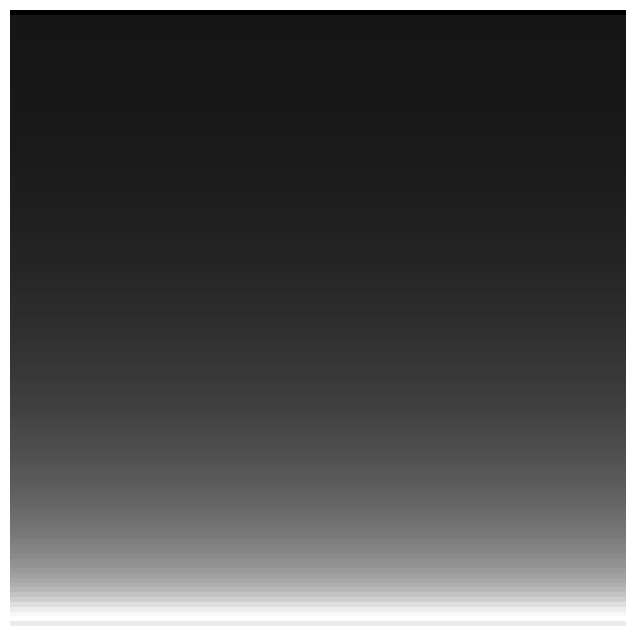

In [ ]:
import matplotlib.pylab as pylab
pylab.figure(figsize=(8,8))
pylab.axis('off')
pylab.imshow(imagee,cmap="gray")

In [ ]:
from scipy.signal import butter,lfilter,freqz
final=[]
#PROCESAMIENTO DE SEÑAL

cutoff = 3.667 #frecuencia de corte rad/s
fs = 14 #sampling frequency rad/s
order = 20 #orden del filtro
sr = 195 #sample rate
for i in range(len(señales)):
  lowpass_muestra = señales[i]
  y = butter_lowpass_filter(lowpass_muestra, cutoff, fs, order)
  lowpass_muestra = y
  smooth_muestra = scipy.signal.savgol_filter(y, 21, 7, mode='nearest')
  lowpass_signals.append(lowpass_muestra)
  smooth_signals.append(smooth_muestra)
  fourier_transform(smooth_muestra)
  spectogram_muestra = image_to_array(smooth_muestra)
  spectogram_signals.append(np.array(spectogram_muestra))

In [ ]:
final=np.array(final)/255

In [ ]:
final.shape

(0,)

In [ ]:
import pandas as pd
import numpy as np
y= pd.read_excel("/content/DATOS SELECCIONADOS.xlsx",header=None).dropna()
y= np.array(y[1])

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
# ajustar en los datos (estandarizados)
pca.fit(final)

PCA(n_components=3)

In [ ]:
descomp=pca.transform(final)

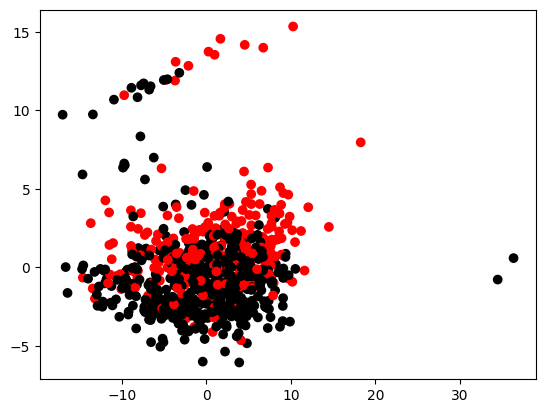

In [ ]:
import matplotlib
colors = ['red','black']
plt.scatter(descomp[:,0],descomp[:,1],c=y,cmap=matplotlib.colors.ListedColormap(colors))

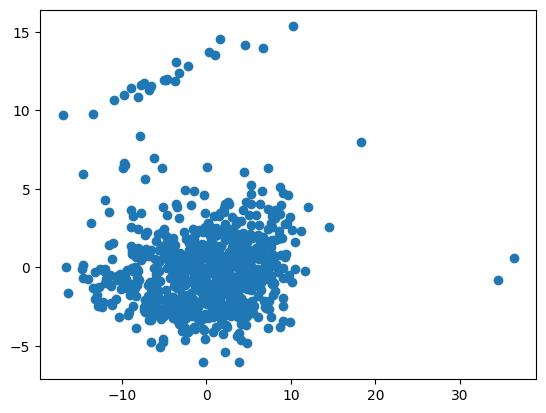

In [ ]:
fig = plt.figure()
fig=plt.scatter(descomp[:,0],descomp[:,1])

plt.show()


In [ ]:
def obtener_numeros_faltantes(lista_strings):
    # Obtener el número más bajo y más alto en la lista original
    numeros_presentes = [int(s.split(".")[0]) for s in lista_strings]
    min_num = min(numeros_presentes)
    max_num = max(numeros_presentes)

    # Crear una lista con todos los números posibles en el rango dado
    numeros_posibles = list(range(min_num, max_num + 1))

    # Encontrar los números faltantes
    numeros_faltantes = [num for num in numeros_posibles if num not in numeros_presentes]

    return numeros_faltantes

# Ejemplo de uso
numeros_faltantes = obtener_numeros_faltantes(nombres)
print(numeros_faltantes)

[7, 677, 717, 718, 719, 739, 740, 741, 742, 743, 744, 745, 746, 747]


In [ ]:
from sklearn import metrics

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(final,y ,random_state=104, test_size=0.4, shuffle=True)

In [ ]:
lda = LDA(solver="svd", store_covariance=True)
model_lda= lda.fit(X_train, y_train)

In [ ]:
predict_lda=model_lda.predict(X_test)

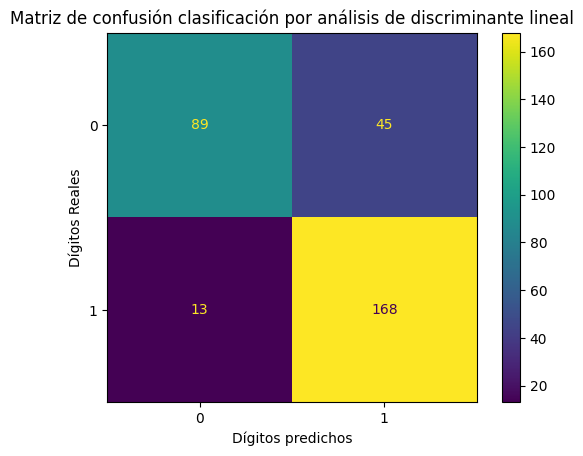

In [ ]:
confusion_matrix = metrics.confusion_matrix(y_test, predict_lda)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix)
cm_display.plot()
cm_display.ax_.set_title("Matriz de confusión clasificación por análisis de discriminante lineal")
cm_display.ax_.set_xlabel("Dígitos predichos")
cm_display.ax_.set_ylabel("Dígitos Reales")
plt.show()

In [ ]:
print(metrics.classification_report(y_test.flatten(), predict_lda))

              precision    recall  f1-score   support

         0.0       0.87      0.66      0.75       134
         1.0       0.79      0.93      0.85       181

    accuracy                           0.82       315
   macro avg       0.83      0.80      0.80       315
weighted avg       0.82      0.82      0.81       315



In [ ]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA

In [ ]:
qda = QDA( store_covariance=True)
model_qda= qda.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/discriminant_analysis.py:926: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")


In [ ]:
predict_qda=model_qda.predict(X_test)

In [ ]:
print(metrics.classification_report(y_test.flatten(), predict_qda))

              precision    recall  f1-score   support

         0.0       0.52      0.57      0.54       134
         1.0       0.66      0.60      0.63       181

    accuracy                           0.59       315
   macro avg       0.59      0.59      0.59       315
weighted avg       0.60      0.59      0.59       315



In [ ]:
from sklearn.linear_model import LogisticRegression as LG
clf = LG(solver='sag', max_iter=100, random_state=42).fit(X_train, y_train)


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [ ]:
predict_logit=clf.predict(X_test)

In [ ]:
print(metrics.classification_report(y_test.flatten(), predict_logit))

              precision    recall  f1-score   support

         0.0       0.85      0.57      0.68       134
         1.0       0.74      0.93      0.83       181

    accuracy                           0.77       315
   macro avg       0.80      0.75      0.75       315
weighted avg       0.79      0.77      0.76       315



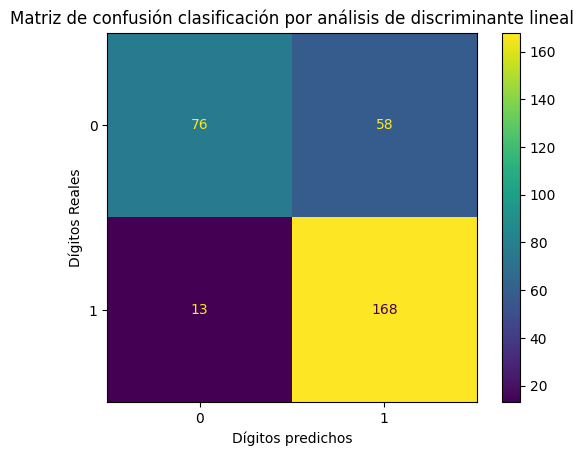

In [ ]:
confusion_matrix = metrics.confusion_matrix(y_test, predict_logit)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix)
cm_display.plot()
cm_display.ax_.set_title("Matriz de confusión clasificación por análisis de discriminante lineal")
cm_display.ax_.set_xlabel("Dígitos predichos")
cm_display.ax_.set_ylabel("Dígitos Reales")
plt.show()

**QDA y LDA**